Script to generate ground truth images

In [9]:
import sys
sys.path.append('E:/OneDrive - UC San Diego/UCSD/Lab/Catheter/diff_catheter/scripts')

In [10]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from cc_catheter import CCCatheter
# from test_cc_catheter import CCCatheter

In [11]:
# scripts_path = 'E:/OneDrive - UC San Diego/UCSD/Lab/Catheter/diff_catheter/data'
# dataset_folder = "target_parameters"
# gt_name = 'target_1'

# file_name = f"{scripts_path}/{dataset_folder}/{gt_name}.npy"
# data = np.load(file_name)
# print(data)
# print(data.shape)

Generate a single ground truth image

In [12]:
p_0 = np.array([2e-2, 2e-3, 0.000001])
l = 0.2
# r = 0.01
r = 0.01
n_mid_points = 1
n_iter = 50
n_trials = 50
ux = 0.0005
uy = 0.0005

cccatheter = CCCatheter(p_0, l, r, False, False, n_mid_points, n_iter)
cccatheter.set_3dof_params(ux, uy, l)
cccatheter.calculate_cc_points()
cccatheter.calculate_beziers_control_points()

In [13]:
folder_path = 'E:/OneDrive - UC San Diego/UCSD/Lab/Catheter/diff_catheter/scripts/test_diff_render_catheter_v2/blender_imgs/'
# file_name = 'test_gt_11'
# curve_specs_path = folder_path + file_name + '.npy'
# img_save_path = folder_path + file_name + '.png'

# cccatheter.render_beziers(curve_specs_path, img_save_path)

# # image = cv2.imread(img_save_path)
# image = plt.imread(img_save_path)
# plt.imshow(image)

Image rendered. Image saved to E:/OneDrive - UC San Diego/UCSD/Lab/Catheter/diff_catheter/scripts/test_diff_render_catheter_v2/blender_imgs/test_gt_14.png


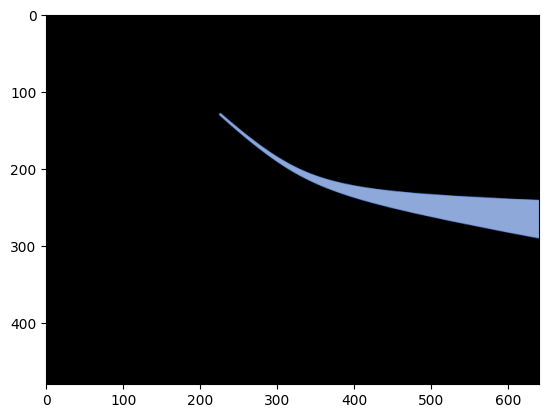

In [14]:
file_name = 'test_gt_14'
curve_specs_path = folder_path + file_name + '.npy'
img_save_path = folder_path + file_name + '.png'

cccatheter.render_beziers(curve_specs_path, img_save_path, viewpoint_mode=1)

# image = cv2.imread(img_save_path)
image = plt.imread(img_save_path)
plt.imshow(image)

In [15]:
# cccatheter2 = CCCatheter(p_0, l, r, n_mid_points, n_iter, n_trials)
# cccatheter2.set_3dof_params(ux, uy, l)
# cccatheter2.calculate_cc_points()
# cccatheter2.calculate_beziers_control_points_3()

# file_name = 'test_gt_3points_2'
# curve_specs_path = folder_path + file_name + '.npy'
# img_save_path = folder_path + file_name + '.png'

# cccatheter2.render_beziers(curve_specs_path, img_save_path)

Generate a series of ground truth images, according to a list of tendon lengths

In [17]:
# Generate a series of numbers from 0 to 0.003 with a step of 0.0002
ux_list = np.arange(0, 0.001, 0.0002)
uy_list = np.arange(0, 0.001, 0.0002)

p_0 = np.array([2e-2, 2e-3, 0])
l = 0.2
r = 0.01
n_mid_points = 1
n_iter = 10
n_trials = 50

folder_path = 'E:/OneDrive - UC San Diego/UCSD/Lab/Catheter/diff_catheter/scripts/test_diff_render_catheter_v2/gt_dataset/'

count = 1
for ux in ux_list:
    for uy in uy_list:
        if ux == 0 and uy == 0:
            continue

        cccatheter = CCCatheter(p_0, l, r, False, False, n_mid_points, n_iter)
        cccatheter.set_3dof_params(ux, uy, l)
        cccatheter.calculate_cc_points()
        cccatheter.calculate_beziers_control_points()
        
        ux_str = f"{ux:.4f}"
        uy_str = f"{uy:.4f}"
        file_name = f"gt_{count}_{ux_str}_{uy_str}_{l}_{r}"
        curve_specs_path = folder_path + file_name + '.npy'
        img_save_path = folder_path + file_name + '.png'

        cccatheter.render_beziers(curve_specs_path, img_save_path)
        
        print(f"Generated {file_name}")
        count += 1
        




Image rendered. Image saved to E:/OneDrive - UC San Diego/UCSD/Lab/Catheter/diff_catheter/scripts/test_diff_render_catheter_v2/gt_dataset6/gt_1_0.0000_0.0002_0.2_0.01.png
Generated gt_1_0.0000_0.0002_0.2_0.01
Image rendered. Image saved to E:/OneDrive - UC San Diego/UCSD/Lab/Catheter/diff_catheter/scripts/test_diff_render_catheter_v2/gt_dataset6/gt_2_0.0000_0.0004_0.2_0.01.png
Generated gt_2_0.0000_0.0004_0.2_0.01
Image rendered. Image saved to E:/OneDrive - UC San Diego/UCSD/Lab/Catheter/diff_catheter/scripts/test_diff_render_catheter_v2/gt_dataset6/gt_3_0.0000_0.0006_0.2_0.01.png
Generated gt_3_0.0000_0.0006_0.2_0.01
Image rendered. Image saved to E:/OneDrive - UC San Diego/UCSD/Lab/Catheter/diff_catheter/scripts/test_diff_render_catheter_v2/gt_dataset6/gt_4_0.0000_0.0008_0.2_0.01.png
Generated gt_4_0.0000_0.0008_0.2_0.01
Image rendered. Image saved to E:/OneDrive - UC San Diego/UCSD/Lab/Catheter/diff_catheter/scripts/test_diff_render_catheter_v2/gt_dataset6/gt_5_0.0002_0.0000_0.2_0.